In [ ]:
from pathlib import Path
import os, sys

# Backwards-compatible aliases for older notebooks
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# Aliases used in various notebooks
out_dir = OUT_DIR
REPORT_DIR = OUT_DIR
RESULTS_PATH = OUT_DIR
print(f"Results directory aliases set: {OUT_DIR}")

In [ ]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

# Ligand-Receptor Experiment

Two-population simulation with fast ligands, slow receptors, type-specific spot widths, and simple binding/unbinding dynamics.

In [31]:
%cd ..
%load_ext autoreload
%autoreload 2
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *
from helpers.helpersPlotting import *

import copy
import pandas as pd
from pathlib import Path

c:\Users\armel\OneDrive - epfl.ch\MA2
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## I. Simulation of the receptors and ligands interactions

In [ ]:
simulation_config = {
    "n_ligands": 10,
    "n_receptors": 5,
    "nframes": 100,
    "nposframe": 10,
    "dt": 1.0,
    "ligand_D": [(4.0, 0.4), (6.0, 0.5), (8.0, 0.1)],
    "receptor_D": [(0.0, 0.3), (0.02, 0.7)],
    "frame_size": (128, 128),
    "boundary_margin": 10,
    "binding_radius": 4.0,
    "kon": 0.65,
    "koff": 0.05,
    "allow_multiple_ligands_per_receptor": False,
    "bound_position_noise": 0.15,
    "ligand_intensity_mean": 600,
    "ligand_intensity_std": 100,
    "receptor_intensity_mean": 500,
    "receptor_intensity_std": 200,
    "ligand_sigma_mean": 0.8,
    "ligand_sigma_std": 0.05,
    "receptor_sigma_mean": 1.0,
    "receptor_sigma_std": 0.1,
}

image_config = {
    "particle_intensity": [700, 300],
    "particle_sigma": [1.0, 0.2],
    "particle_type_props": {
        "ligand": {
            "particle_intensity": [550, 100],
            "particle_sigma": [1.0, 0.05],
        },
        "receptor": {
            "particle_intensity": [500, 200],
            "particle_sigma": [1.0, 0.08],
        },
    },
    "use_trajectory_sigma": True,
    "background_intensity": [150, 50],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = LigandReceptorSimulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
ligands_GT = sim.get_ligands()
receptors_GT = sim.get_receptors()
binding_events = sim.binding_events
video_ligand_receptor = sim.video

In [3]:
print(f"Ligands: {len(ligands_GT)}")
print(f"Receptors: {len(receptors_GT)}")
print(f"Binding events: {len(binding_events)}")

if binding_events:
    durations = [event["end_subframe"] - event["start_subframe"] + 1 for event in binding_events]
    print(f"Mean bound duration: {np.mean(durations):.2f} subframes")
    print(binding_events[:5])

Ligands: 10
Receptors: 5
Binding events: 12
Mean bound duration: 104.50 subframes
[{'ligand_id': 9, 'receptor_id': 3, 'start_subframe': 67, 'end_subframe': 118, 'start_frame': 6, 'end_frame': 11}, {'ligand_id': 9, 'receptor_id': 3, 'start_subframe': 120, 'end_subframe': 356, 'start_frame': 12, 'end_frame': 35}, {'ligand_id': 11, 'receptor_id': 1, 'start_subframe': 171, 'end_subframe': 175, 'start_frame': 17, 'end_frame': 17}, {'ligand_id': 5, 'receptor_id': 1, 'start_subframe': 321, 'end_subframe': 359, 'start_frame': 32, 'end_frame': 35}, {'ligand_id': 9, 'receptor_id': 3, 'start_subframe': 357, 'end_subframe': 375, 'start_frame': 35, 'end_frame': 37}]


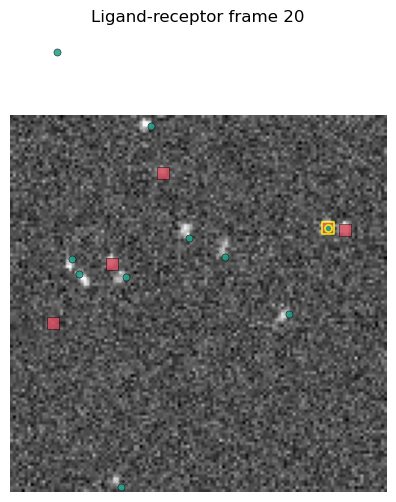

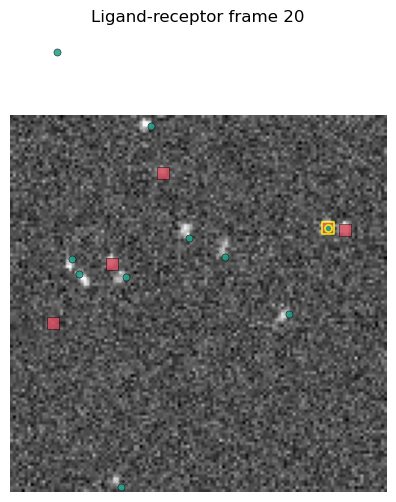

In [4]:
plot_ligand_receptor_frame(sim, frame_id=20, show_ids=False)

In [1]:
sim.animate(interval=100)

NameError: name 'sim' is not defined

## II. Regular vs masked tracking comparison

The comparison below keeps the simulation, peak extraction, cost defaults, and ligand-friendly tracking parameters fixed. The only experimental difference is whether a conservative static-receptor pass is used to remove receptor peaks before tracking the mobile population.


In [6]:
METHOD_ORDER = ["Regular pipeline", "Separated pipeline"]
METHOD_COLORS = {
    "Regular pipeline": "#4c78a8",
    "Separated pipeline": "#f58518",
}
TYPE_COLORS = {
    "ligand": "#1f9e89",
    "receptor": "#d1495b",
    "unassigned": "#6b7280",
}

EVALUATION_TOLERANCE_PX = 3.0
REPORT_DIR = OUT_DIR
REPORT_DIR.mkdir(exist_ok=True)
REPORT_FIGURE_BASE = REPORT_DIR / "LigandReceptor_tracking_comparison"
FRAME_FOR_FIGURE = min(20, simulation_config["nframes"] - 1)

PEAK_EXTRACTION_KWARGS = {
    "mode": "localization",
    "detection_threshold": 300,
    "r_squared_threshold": 0.35,
    "verbose_loc": False,
    "visualization_loc": False,
}

STATIC_COST = PeakToPeak(terms={
    "distance": DistanceTerm(weight=0.75, norm=2.0),
    "sigma": SigmaTerm(weight=0.25, norm=0.25),
})

STATIC_PASS_KWARGS = {
    "mode": "localization",
    "detection_threshold": 450,
    "r_squared_threshold": 0.5,
    "max_distance": 1.5,
    "min_length": 30,
    "max_gap": 0,
    "algo_peak2peak": "hungarian",
    "cost_func_peak2peak": STATIC_COST,
    "algo_traj2traj": "hungarian",
    "cost_func_traj2traj": None,
    "verbose_assignment": False,
}

MOBILE_TRACKING_KWARGS = {
    "max_distance": 14,
    "min_length": 2,
    "max_gap": 5,
    "stitch_fragments": True,
    "stitch_max_gap": 8,
    "stitch_base_distance": 12,
    "stitch_kwargs": {"max_link_cost": 2.5, "gap_weight": 0.05}, # favors stitching over short gap closing, and allows stitching of more distant fragments
    "verbose_stitching": False,
    "algo_peak2peak": "hungarian",
    "cost_func_peak2peak": None,
    "algo_traj2traj": "hungarian",
    "cost_func_traj2traj": None,
    "verbose_assignment": False,
}

BRIDGE_KWARGS = {
    "max_gap": 14,
    "anchor_radius": 2*simulation_config["binding_radius"],
    "max_link_cost": 2.5,
    "gap_weight": 0.04,
    "fill_bound_frames": True,
    "return_diagnostics": True,
    "verbose": False,
}

In [7]:
# Extract peaks once so both methods start from the same detections.
peaks_for_tracking = extract_peaks(frames, **PEAK_EXTRACTION_KWARGS)
print(f"Common localized peaks: {count_peaks(peaks_for_tracking)}")

# Regular pipeline: run ligand-friendly tracking on all localized peaks.
regular_trajs, regular_cost_peak2peak, regular_assignment, regular_cost_traj2traj = track_from_peaks(
    copy.deepcopy(peaks_for_tracking),
    trajectories_GT,
    **MOBILE_TRACKING_KWARGS,
)

regular_metrics = evaluate_tracking_method(
    "Regular pipeline",
    regular_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

print(f"Regular pipeline tracking: {len(regular_trajs)} final trajectories")
print(f"  peak-to-peak cost frames: {len(regular_cost_peak2peak)}")
print(f"  GT assignment cost: {regular_cost_traj2traj:.3f}")


Common localized peaks: 700
Regular pipeline tracking: 25 final trajectories
  peak-to-peak cost frames: 99
  GT assignment cost: 28.288


In [8]:
# Separated pipeline.
# 1) Conservative pass finds long, nearly static receptor candidates.
static_results = sim.track(**STATIC_PASS_KWARGS)
static_candidate_trajs = copy.deepcopy(static_results[0])

static_candidate_metrics = evaluate_tracking_method(
    "Static pass",
    static_candidate_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

static_candidate_table = (
    static_candidate_metrics["tracks"]
    .groupby("type", dropna=False)
    .agg(n_tracks=("track_idx", "count"), median_error_px=("median_error_px", "median"))
    .reset_index()
)

print(f"Static pass candidates: {len(static_candidate_trajs)}")
display(static_candidate_table)

# 2) Remove those static peaks from the common peak list, keeping anchor diagnostics.
masked_peaks_for_tracking, removed_static_peak_records = remove_static_peaks(
    copy.deepcopy(peaks_for_tracking),
    static_candidate_trajs,
    tolerance=EVALUATION_TOLERANCE_PX,
    return_removed=True,
    verbose=False,
)

removed_peaks = count_peaks(peaks_for_tracking) - count_peaks(masked_peaks_for_tracking)
print(f"Peaks removed by the static mask: {removed_peaks}")
print(f"Stored static-anchor records: {len(removed_static_peak_records)}")
print(f"Peaks kept for mobile tracking: {count_peaks(masked_peaks_for_tracking)}")

# 3) Track remaining mobile peaks with the same parameters as the regular pipeline.
masked_mobile_trajs, masked_mobile_cost_peak2peak, _, _ = track_from_peaks(
    copy.deepcopy(masked_peaks_for_tracking),
    trajectories_GT,
    **MOBILE_TRACKING_KWARGS,
)

# 4) Reconnect mobile fragments through the static receptor anchors.
bridged_mobile_trajs, bridge_diagnostics = bridge_mobile_fragments_through_static_anchors(
    masked_mobile_trajs,
    static_candidate_trajs,
    **BRIDGE_KWARGS,
)
print(
    "Bridge links: "
    f"{len(bridge_diagnostics['links'])}, "
    f"filled inferred bound frames: {bridge_diagnostics['filled_frames']}"
)

# 5) Add the static candidates back, then assign the combined output to GT once.
masked_combined_trajs = copy.deepcopy(bridged_mobile_trajs) + copy.deepcopy(static_candidate_trajs)
masked_combined_trajs, masked_cost_traj2traj, masked_assignment = assign_trajectories(
    masked_combined_trajs,
    trajectories_GT,
    cost_function=None,
    verbose=False,
)

masked_metrics = evaluate_tracking_method(
    "Separated pipeline",
    masked_combined_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

print(f"Separated pipeline tracking: {len(masked_combined_trajs)} final trajectories")
print(f"  mobile peak-to-peak cost frames: {len(masked_mobile_cost_peak2peak)}")
print(f"  combined GT assignment cost: {masked_cost_traj2traj:.3f}")


Static pass candidates: 3


,type,n_tracks,median_error_px
0,receptor,3,0.581053


Peaks removed by the static mask: 245
Stored static-anchor records: 245
Peaks kept for mobile tracking: 455
Bridge links: 0, filled inferred bound frames: 0
Separated pipeline tracking: 28 final trajectories
  mobile peak-to-peak cost frames: 99
  combined GT assignment cost: 28.418


In [9]:
summary_table = combined_summary_table(regular_metrics, masked_metrics)
summary_display = summary_table.copy()
for col in ["mean_coverage_pct", "mean_good_fragments", "median_error_px", "within_tolerance_pct"]:
    summary_display[col] = summary_display[col].round(2)

display(summary_display)

state_summary = (
    pd.concat([regular_metrics["states"], masked_metrics["states"]], ignore_index=True)
    .groupby(["method", "type", "state"], as_index=False)
    .agg(
        n_frames=("n_frames", "sum"),
        recovered_frames=("recovered_frames", "sum"),
    )
)
state_summary["coverage_pct"] = 100 * state_summary["recovered_frames"] / state_summary["n_frames"]
display(state_summary.round({"coverage_pct": 2}))

print("Method differences, separated minus regular:")
for population in ["all", "ligand", "receptor"]:
    regular_row = summary_table[(summary_table["method"] == "Regular pipeline") & (summary_table["population"] == population)].iloc[0]
    masked_row = summary_table[(summary_table["method"] == "Separated pipeline") & (summary_table["population"] == population)].iloc[0]
    delta_cov = masked_row["mean_coverage_pct"] - regular_row["mean_coverage_pct"]
    delta_err = masked_row["median_error_px"] - regular_row["median_error_px"]
    delta_tracks = masked_row["tracks"] - regular_row["tracks"]
    print(
        f"  {population:8s}: coverage {delta_cov:+.1f} pp, "
        f"median error {delta_err:+.2f} px, tracks {delta_tracks:+.0f}"
    )


,method,population,gt_count,tracks,unassigned_tracks,mean_coverage_pct,recovered_gt_ge50,mean_good_fragments,median_error_px,within_tolerance_pct
0,Regular pipeline,all,15,25,10,31.53,4,0.87,0.69,79.23
1,Regular pipeline,ligand,10,10,0,12.60,0,0.90,2.24,60.00
2,Regular pipeline,receptor,5,5,0,69.40,4,0.80,0.61,89.66
3,Separated pipeline,all,15,28,13,30.80,3,0.87,0.67,83.39
4,Separated pipeline,ligand,10,10,0,12.30,0,0.90,2.10,63.73
5,Separated pipeline,receptor,5,5,0,67.80,3,0.80,0.60,93.91


,method,type,state,n_frames,recovered_frames,coverage_pct
0,Regular pipeline,ligand,bound,124,11,8.87
1,Regular pipeline,ligand,free,876,115,13.13
2,Regular pipeline,receptor,bound,124,113,91.13
3,Regular pipeline,receptor,free,376,234,62.23
4,Separated pipeline,ligand,bound,124,19,15.32
5,Separated pipeline,ligand,free,876,104,11.87
6,Separated pipeline,receptor,bound,124,105,84.68
7,Separated pipeline,receptor,free,376,234,62.23


Method differences, separated minus regular:
  all     : coverage -0.7 pp, median error -0.02 px, tracks +3
  ligand  : coverage -0.3 pp, median error -0.15 px, tracks +0
  receptor: coverage -1.6 pp, median error -0.01 px, tracks +0


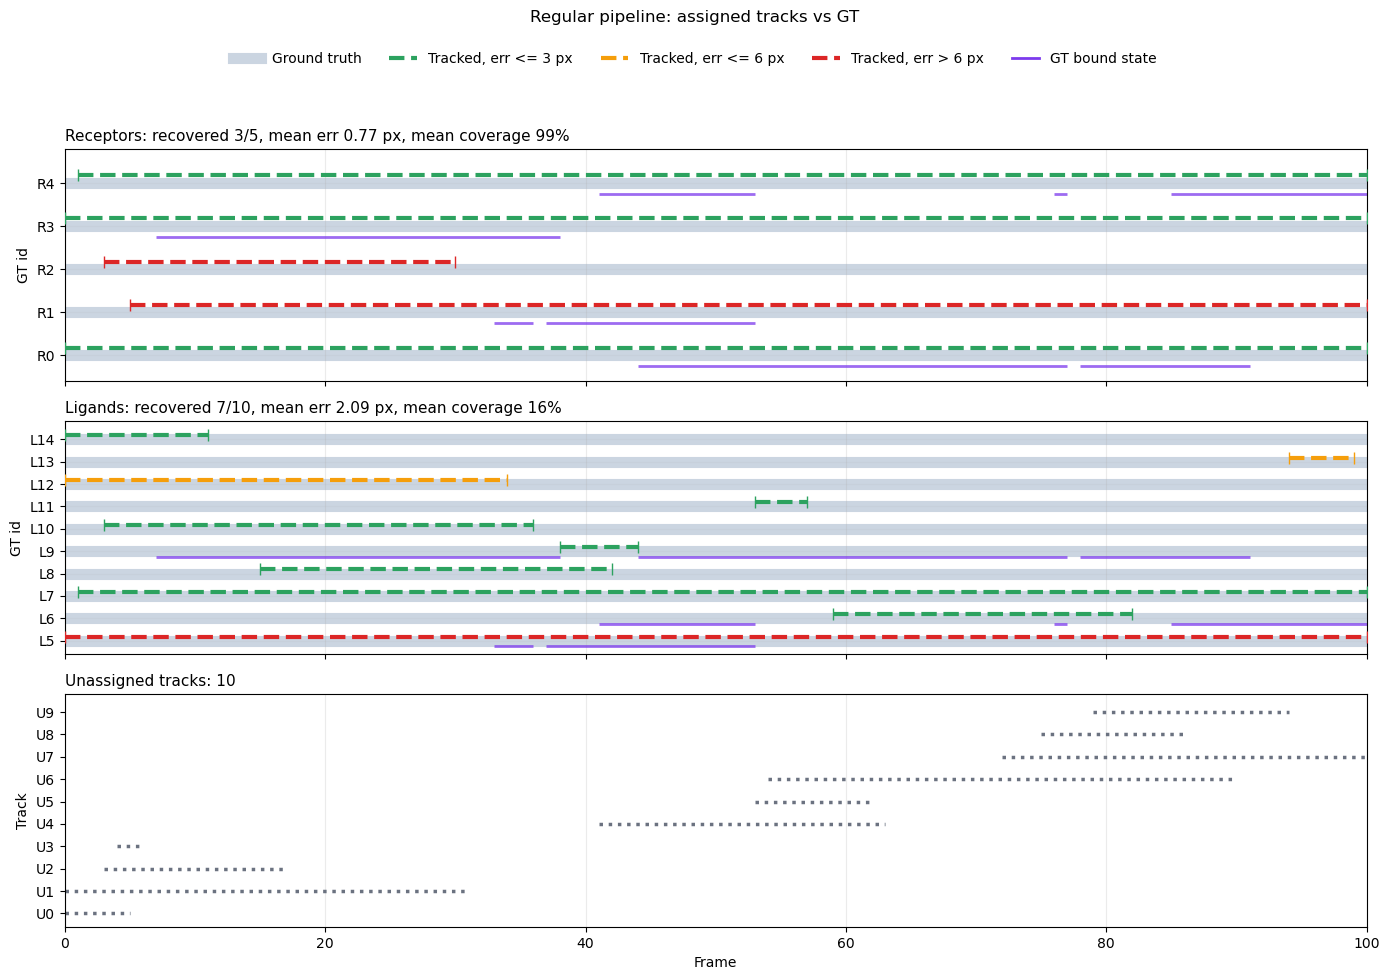

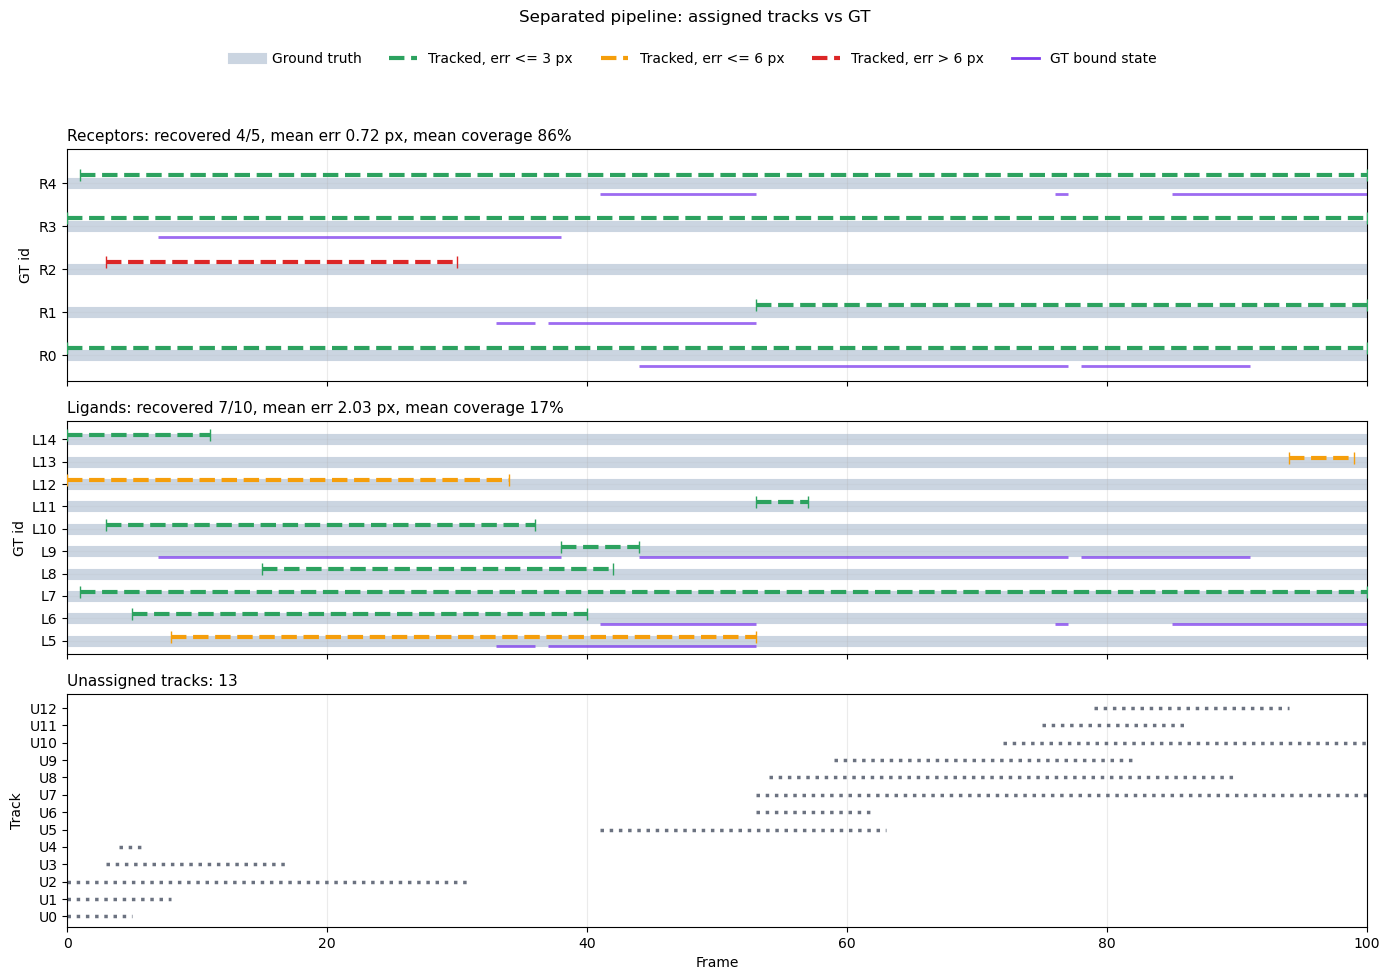

In [10]:
linear_trajectories_visualizer(
    regular_trajs,
    trajectories_GT,
    quality_tolerance=EVALUATION_TOLERANCE_PX,
    show_labels=False,
    title="Regular pipeline: assigned tracks vs GT",
)

linear_trajectories_visualizer(
    masked_combined_trajs,
    trajectories_GT,
    quality_tolerance=EVALUATION_TOLERANCE_PX,
    show_labels=False,
    title="Separated pipeline: assigned tracks vs GT",
)


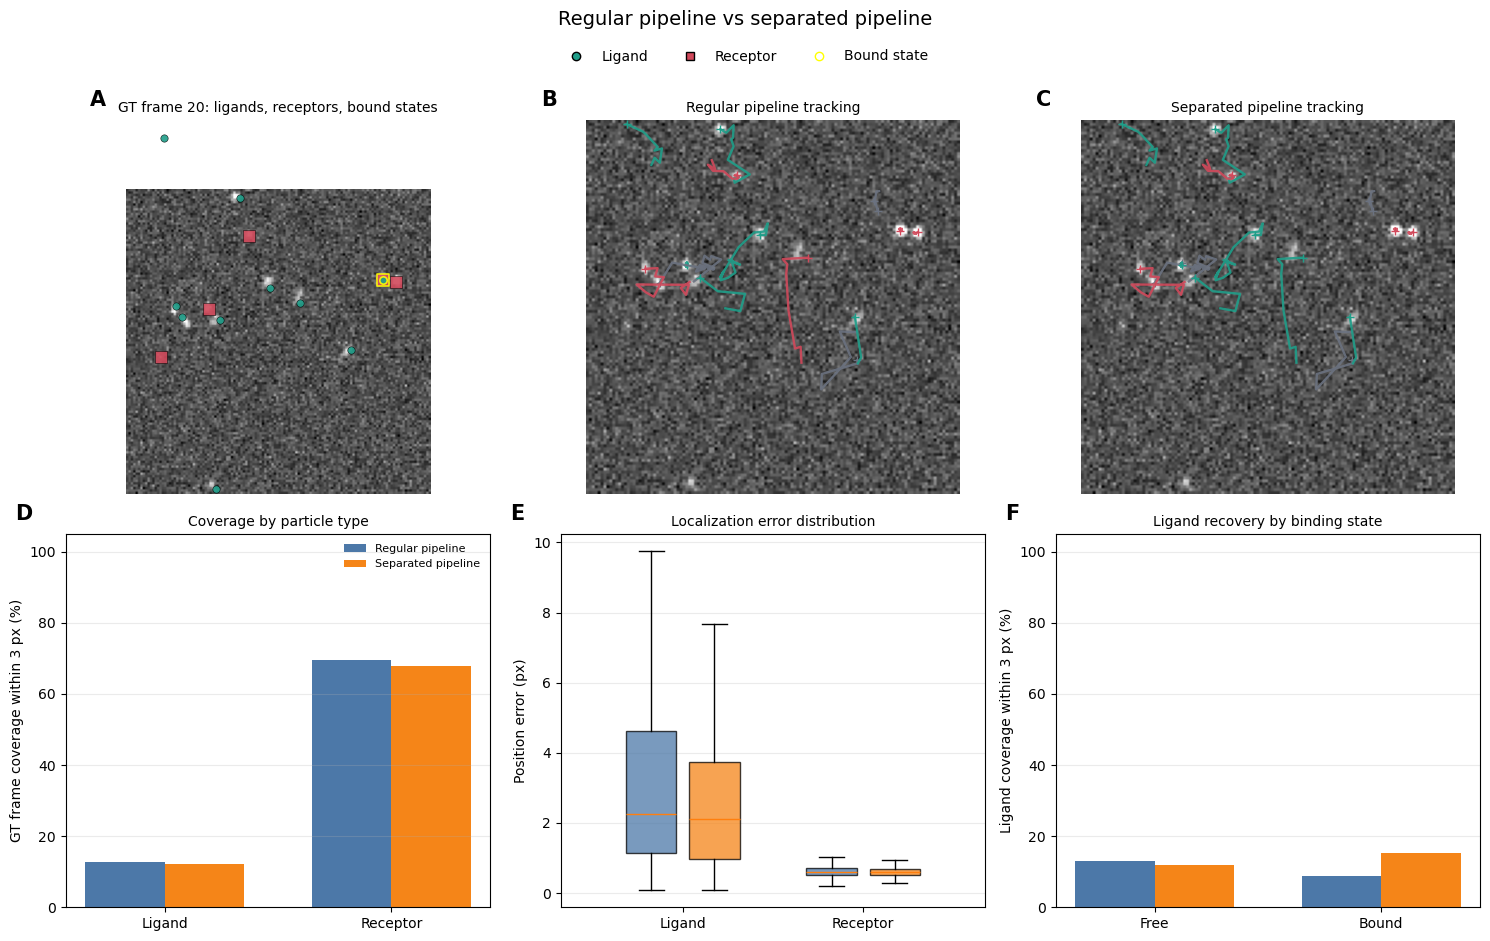

Saved report figure to Experiments\LigandReceptor_tracking_comparison.png
Saved report figure to Experiments\LigandReceptor_tracking_comparison.pdf


In [11]:
fig, saved_paths = plot_ligand_receptor_comparison_figure(
    sim=sim,
    frames=frames,
    trajectories_GT=trajectories_GT,
    method_trajectories={
        "Regular pipeline": regular_trajs,
        "Separated pipeline": masked_combined_trajs,
    },
    method_metrics={
        "Regular pipeline": regular_metrics,
        "Separated pipeline": masked_metrics,
    },
    summary_table=summary_table,
    state_summary=state_summary,
    frame_id=FRAME_FOR_FIGURE,
    save_base=REPORT_FIGURE_BASE,
    method_order=METHOD_ORDER,
    method_colors=METHOD_COLORS,
    type_colors=TYPE_COLORS,
    track_titles={
        "Regular pipeline": "Regular pipeline tracking",
        "Separated pipeline": "Separated pipeline tracking",
    },
    figure_title="Regular pipeline vs separated pipeline",
    tolerance_px=EVALUATION_TOLERANCE_PX,
)
plt.show()
for saved_path in saved_paths:
    print(f"Saved report figure to {saved_path}")


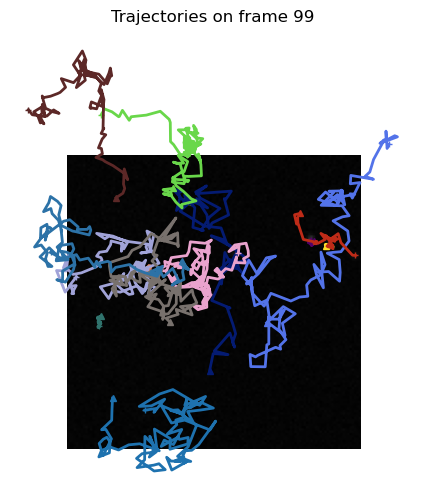

In [12]:
show_trajectories(frames, trajectories_GT, frame_id=simulation_config["nframes"]-1)

In [13]:
def save_video_to_tiff(video, path, fps=10):
    import tifffile
    # Convert video to uint16 for saving, scaling intensities to fill the range.
    video_uint16 = (video / video.max() * 65535).astype(np.uint16)
    tifffile.imwrite(path, video_uint16)

save_path = "ligand_receptor_simulation_video.tiff"

save_video_to_tiff(video_ligand_receptor, save_path)
print(f"Saved simulation video to {REPORT_DIR / 'ligand_receptor_simulation_video.tiff'}")


Saved simulation video to Experiments\ligand_receptor_simulation_video.tiff


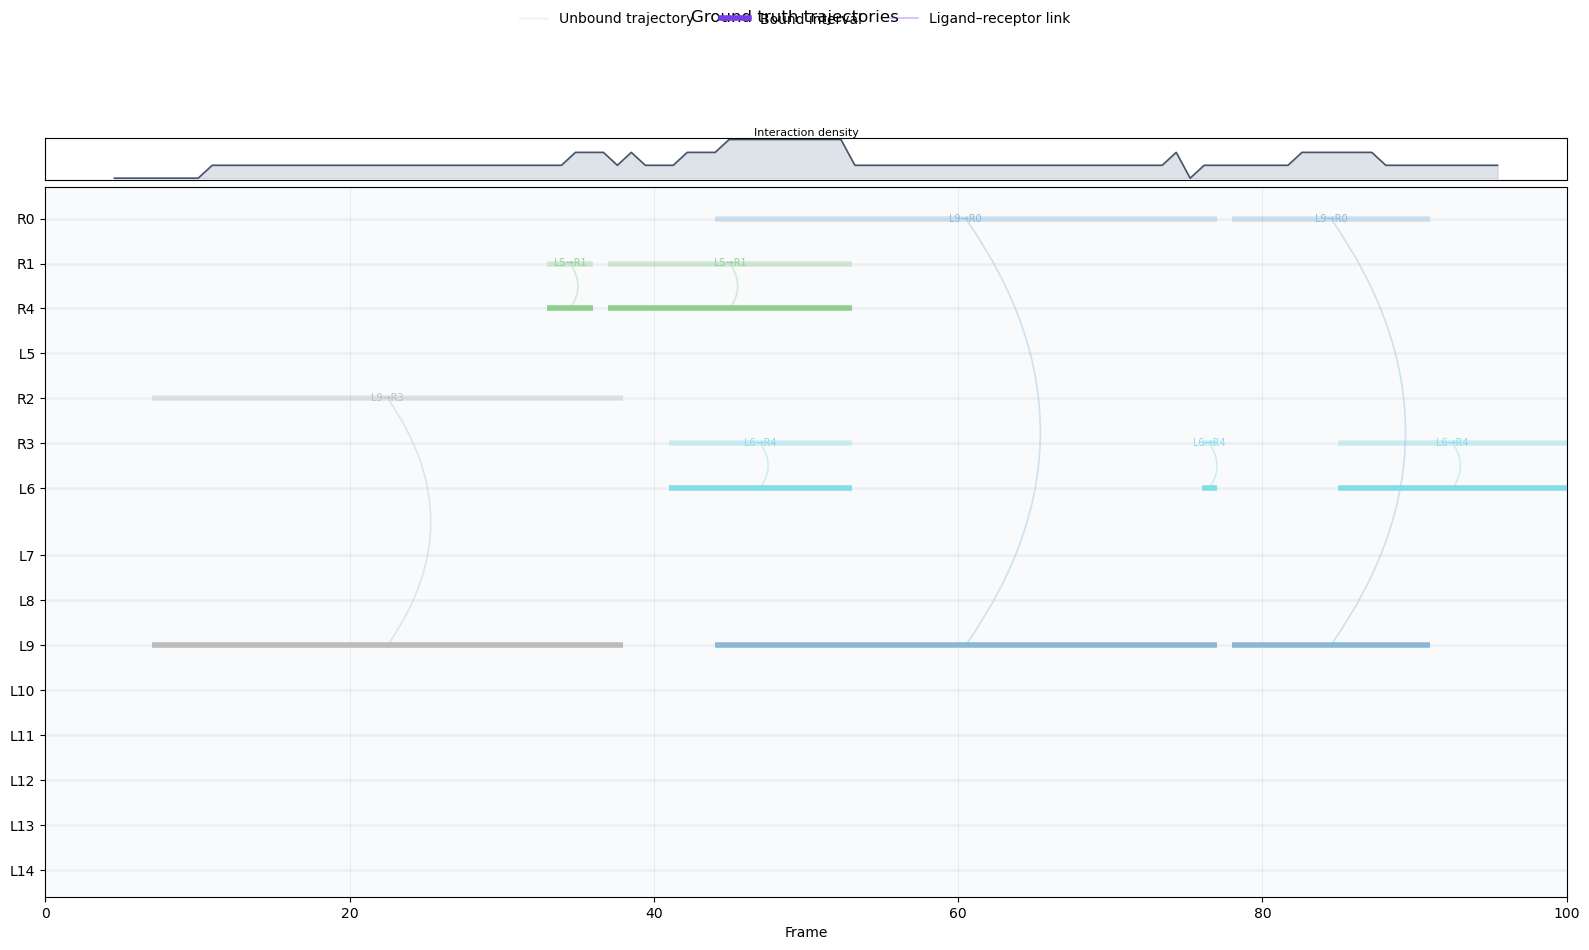

In [14]:
GT_linear_visualizer(sim, title="Ground truth trajectories")

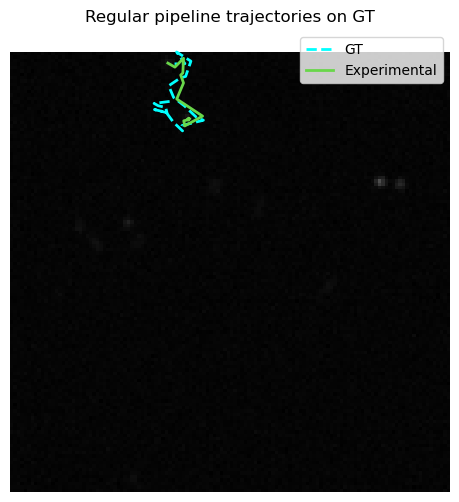

In [46]:
show_traj_on_GT(frames, regular_trajs, trajectories_GT, traj_id=12, frame_id=FRAME_FOR_FIGURE, title="Regular pipeline trajectories on GT")